Causal Forest

Aim: estimate hterogeneous treatment effects of the X5 SMS marketing intervention on post-treatment purchase incidence using pre-treatment customer characteristics

1. Imports

In [20]:
import pandas as pd
import numpy as np

from pathlib import Path
from sklearn.model_selection import train_test_split
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
RANDOM_STATE = 1213 #can change

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "retailhero_causal_forest_features.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "output" 
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading data from {DATA_PATH}")
print(f"Saving output to {OUTPUT_DIR}")







Reading data from C:\Users\szepi\OneDrive\Documents\dse4101\DSE4101-CausalForest-Grp2\data\processed\retailhero_causal_forest_features.csv
Saving output to C:\Users\szepi\OneDrive\Documents\dse4101\DSE4101-CausalForest-Grp2\data\output


2. Load and inspect dataset

In [4]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Dataset columns: {df.columns.tolist()}")
print(f"treatment distribution: {df['treatment'].value_counts(normalize=True)}")
print(f"target distribution: {df['target'].value_counts(normalize=True)}")
display(df.head())

Dataset shape: (200039, 25)
Dataset columns: ['client_id', 'age', 'gender_F', 'gender_M', 'gender_U', 'num_transactions', 'num_unique_products', 'num_stores_visited', 'total_quantity', 'avg_items_per_transaction', 'total_spend', 'avg_transaction_spend', 'median_transaction_spend', 'spend_std', 'regular_points_received', 'regular_points_spent', 'express_points_received', 'express_points_spent', 'net_regular_points_change', 'net_express_points_change', 'days_since_last_purchase', 'avg_days_between_transactions', 'customer_activity_span', 'treatment', 'target']
treatment distribution: treatment
0    0.500192
1    0.499808
Name: proportion, dtype: float64
target distribution: target
1    0.619889
0    0.380111
Name: proportion, dtype: float64


,client_id,age,gender_F,gender_M,gender_U,num_transactions,num_unique_products,num_stores_visited,total_quantity,avg_items_per_transaction,...,regular_points_spent,express_points_received,express_points_spent,net_regular_points_change,net_express_points_change,days_since_last_purchase,avg_days_between_transactions,customer_activity_span,treatment,target
0,000012768d,45,0,0,1,4,46,3,54.0,13.500000,...,0.0,0.0,0.0,25.7,0.0,4,34.441906,103,0,1
1,000036f903,72,1,0,0,32,96,5,169.0,5.281250,...,0.0,60.0,0.0,54.9,60.0,1,3.515704,108,1,1
2,00010925a5,83,0,0,1,18,58,2,79.0,4.388889,...,-17.0,0.0,0.0,14.8,0.0,10,6.049572,102,1,1
3,0001f552b0,33,1,0,0,15,79,4,106.0,7.066667,...,0.0,0.0,0.0,78.9,0.0,2,8.010879,112,1,1
4,00020e7b18,73,0,0,1,18,175,4,394.0,21.888889,...,-592.0,0.0,-30.0,-305.9,-30.0,3,6.597343,112,1,1


3. Define modelling variables

In [8]:
Y = df['target'].astype(int)
Z = df['treatment'].astype(int)
exclude_cols = ['target', 'treatment', 'client_id']
X = df.drop(columns=exclude_cols).copy()
X = X.drop(columns = ["gender_U"], errors='ignore') # drop gender_U 

print("Covariates:")
for col in X.columns:
    print(f" - {col}")

print(f"treatment distribution: {Z.value_counts(normalize=True)}")
print(f"target distribution: {Y.value_counts(normalize=True)}")

Covariates:
 - age
 - gender_F
 - gender_M
 - num_transactions
 - num_unique_products
 - num_stores_visited
 - total_quantity
 - avg_items_per_transaction
 - total_spend
 - avg_transaction_spend
 - median_transaction_spend
 - spend_std
 - regular_points_received
 - regular_points_spent
 - express_points_received
 - express_points_spent
 - net_regular_points_change
 - net_express_points_change
 - days_since_last_purchase
 - avg_days_between_transactions
 - customer_activity_span
treatment distribution: treatment
0    0.500192
1    0.499808
Name: proportion, dtype: float64
target distribution: target
1    0.619889
0    0.380111
Name: proportion, dtype: float64


4. Train test split

In [9]:
strata = Z.astype(str) + "_" + Y.astype(str)
X_train, X_test, Y_train, Y_test, Z_train, Z_test = train_test_split(
    X, Y, Z, test_size=0.3, random_state=RANDOM_STATE, stratify=strata)

print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")
print(f"Train treatment distribution: {Z_train.value_counts(normalize=True)}")
print(f"Train target distribution: {Y_train.value_counts(normalize=True)}")

# ensure no overlapping customers
assert X_train.index.intersection(X_test.index).empty, "Train and test sets have overlapping customers"
print("Train and test sets have no overlapping customers, Train/test seperation verified")

Train set shape: (140027, 21), Test set shape: (60012, 21)
Train treatment distribution: treatment
0    0.500196
1    0.499804
Name: proportion, dtype: float64
Train target distribution: target
1    0.619888
0    0.380112
Name: proportion, dtype: float64
Train and test sets have no overlapping customers, Train/test seperation verified


5. Nuisance Model : used to perform local centering so that causal forest can focus on how treatment effect varies across customers

In [13]:
# Outcome nuisance model E[Y|X]
model_y = RandomForestRegressor(n_estimators=100, min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=1)

# Treatment nuisance model E[Z=1|X]
model_z = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)

print("Outcome nuisance model:")
print(model_y)
print("Treatment nuisance model:")
print(model_z)

Outcome nuisance model:
RandomForestRegressor(min_samples_leaf=20, n_jobs=1, random_state=1213)
Treatment nuisance model:
DummyClassifier(random_state=1213)


6. Configure and Fit Causal Forest

In [16]:
cf = CausalForestDML(
    model_y=model_y,
    model_t=model_z,
    discrete_treatment=True,
    n_estimators=200,
    min_samples_leaf=20,
    cv=3,
    honest=True,
    inference=True,
    random_state=RANDOM_STATE,
    n_jobs=1)

print("Causal forest configured successfully:")
print(cf)

print("Training causal forest...")

cf.fit(
    Y=Y_train.to_numpy(),
    T=Z_train.to_numpy(),
    X=X_train.to_numpy()
)

print("Causal forest training completed!")

Causal forest configured successfully:
Training causal forest...
Causal forest training completed!


In [22]:
cate_test = cf.effect(X_test.to_numpy())
cate_results = pd.DataFrame({
    "client_id": df.loc[X_test.index, "client_id"].to_numpy(),
    "treatment": Z_test.to_numpy(),
    "target": Y_test.to_numpy(),
    "cate_hat": cate_test})

print(f"CATE results shape: {cate_results.shape}")
print(f"\nFirst 10 customers with their estimated CATE:")
print(cate_results.head(10))
print(f"\nCATE summary statistics:")
display(cate_results.describe())
print(f"\nMean estimated CATE: {cate_test.mean():.4f}")
print(f"Median estimated CATE: {np.median(cate_test):.4f}")
print(f"\nPositive CATE: {(cate_test > 0).mean():.2%}")
print(f"Negative CATE: {(cate_test < 0).mean():.2%}")

# save CATE results to CSV
OUTPUT_CATE_PATH = OUTPUT_DIR / "cf_cate_results.csv"
cate_results.to_csv(OUTPUT_CATE_PATH, index=False)
print(f"CATE results saved to {OUTPUT_CATE_PATH}")

CATE results shape: (60012, 4)

First 10 customers with their estimated CATE:
    client_id  treatment  target  cate_hat
0  21f51c5fe4          1       0  0.028090
1  42e4ff971e          1       1  0.013701
2  662ab81726          0       1  0.038340
3  bcc3a7c229          1       1  0.023328
4  a85afdc2c1          0       0 -0.006734
5  8759da9579          0       1  0.037591
6  120947fc48          0       1  0.040935
7  1535ff9712          1       1  0.024762
8  2d1fadbeaa          1       1  0.021130
9  e9d80b2611          0       1  0.047622

CATE summary statistics:


,treatment,target,cate_hat
count,60012.000000,60012.000000,60012.000000
mean,0.499817,0.619893,0.031619
std,0.500004,0.485417,0.029243
min,0.000000,0.000000,-0.045153
25%,0.000000,0.000000,0.013723
50%,0.000000,1.000000,0.027608
75%,1.000000,1.000000,0.044138
max,1.000000,1.000000,0.408425



Mean estimated CATE: 0.0316
Median estimated CATE: 0.0276

Positive CATE: 92.60%
Negative CATE: 7.40%
CATE results saved to C:\Users\szepi\OneDrive\Documents\dse4101\DSE4101-CausalForest-Grp2\data\output\cf_cate_results.csv


Distribution of CATE

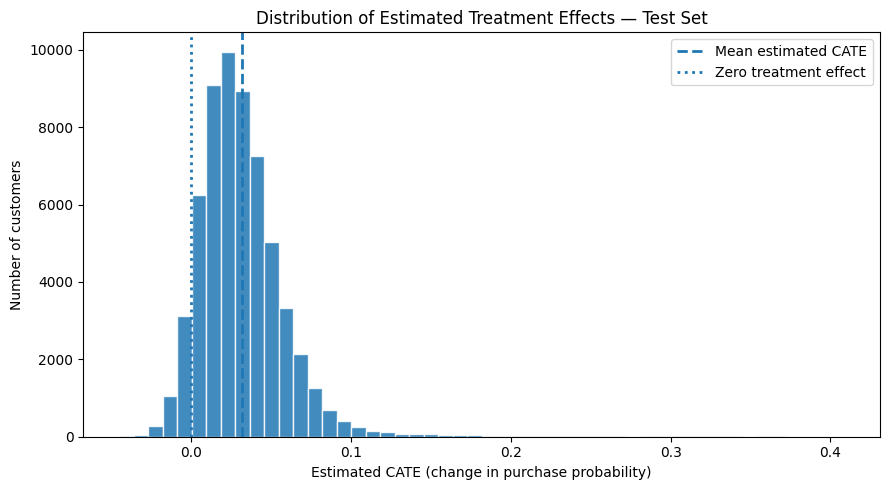

In [21]:
plt.figure(figsize=(9, 5))

plt.hist(cate_results["cate_hat"],bins=50,edgecolor="white",alpha=0.85)

plt.axvline(
    cate_results["cate_hat"].mean(),
    linestyle="--",
    linewidth=2,
    label="Mean estimated CATE"
)

plt.axvline(
    0,
    linestyle=":",
    linewidth=2,
    label="Zero treatment effect"
)

plt.xlabel("Estimated CATE (change in purchase probability)")
plt.ylabel("Number of customers")
plt.title("Distribution of Estimated Treatment Effects — Test Set")
plt.legend()
plt.tight_layout()
plt.show()

Comparison of CATE and ATE

In [24]:
ate_test = (Y_test[Z_test==1].mean() - Y_test[Z_test==0].mean())
mean_cate = cate_results["cate_hat"].mean()
print(f"Experimental test-set ATE: {ate_test:.4f}")
print(f"Mean estimated CATE:      {mean_cate:.4f}")
print(f"Difference:               {mean_cate - ate_test:.4f}")

Experimental test-set ATE: 0.0332
Mean estimated CATE:      0.0316
Difference:               -0.0016


Saving fitted model

In [23]:
import joblib
MODEL_PATH = OUTPUT_DIR / "causal_forest_model.joblib"
joblib.dump(cf, MODEL_PATH)
print(f"Causal forest model saved to {MODEL_PATH}")

Causal forest model saved to C:\Users\szepi\OneDrive\Documents\dse4101\DSE4101-CausalForest-Grp2\data\output\causal_forest_model.joblib
